In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [62]:
df = pd.read_csv('https://raw.githubusercontent.com/Wahid-vinchenzo/phitron-Machine-Learning/refs/heads/main/Exploratory%20Dataset/titanic_data_updated.csv')

In [63]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
df.shape

(891, 12)

In [65]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


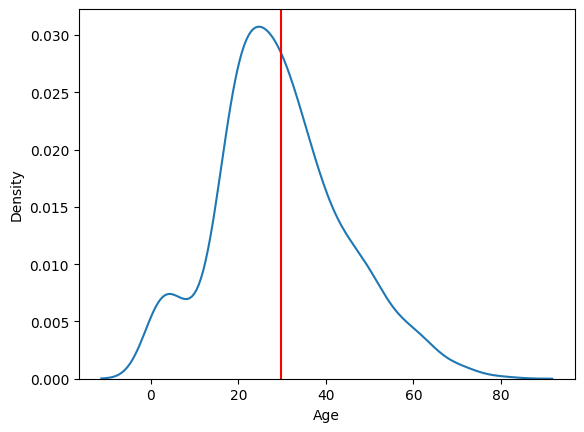

In [66]:
from matplotlib.typing import LineStyleType
sns.kdeplot(data = df, x='Age')
plt.axvline(df['Age'].mean(), color='red')
plt.show()

In [67]:
print((df['Age'].skew()))

0.38910778230082704


### With a skewness score of 0.389 for 'Age', which indicates a slight positive skew,
### median imputation is generally recommended.
### The median is less sensitive to outliers and skewed distributions compared to the mean,
### making it a more robust choice for filling missing values in such cases.
### While the skewness is not extremely high (often considered fairly symmetrical if between -0.5 and 0.5),
### using the median ensures that the imputation is not unduly influenced by the tail of the distribution.

In [68]:
df.dropna(subset=['Embarked'], inplace=True)

In [69]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [70]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [71]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,

)

In [72]:
X_train.shape

(711, 11)

In [73]:
X_test.shape

(178, 11)

In [74]:
y_train.shape

(711,)

In [75]:
y_test.shape

(178,)

In [76]:
#age imputation using SimpleImputer

age_imputer = SimpleImputer(strategy='median')

#fit

age_imputer.fit_transform(X_train[['Age']])

X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()
X_test['Age'] = age_imputer.transform(X_test[['Age']]).ravel()

In [77]:
X_train['Age'].isnull().sum()

np.int64(0)

In [78]:
X_test['Age'].isnull().sum()

np.int64(0)

In [79]:
# impute cabin using most frequent

cabin_imputer = SimpleImputer(strategy ='most_frequent')

# fit
cabin_imputer.fit_transform(X_train[['Cabin']])

X_train['Cabin'] = cabin_imputer.transform(X_train[['Cabin']]).ravel()
X_test['Cabin'] = cabin_imputer.transform(X_test[['Cabin']]).ravel()


In [80]:
X_train['Cabin'].isnull().sum()

np.int64(0)

In [81]:
X_test['Cabin'].isnull().sum()

np.int64(0)

In [82]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### **for diabetes dataset**

In [83]:
df = pd.read_csv('https://raw.githubusercontent.com/Wahid-vinchenzo/phitron-Machine-Learning/refs/heads/main/dataset/diabetes.csv')

In [84]:
df = pd.DataFrame(df)

In [85]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [86]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [88]:
df['Glucose'].unique()

array([148,  85, 183,  89, 137, 116,  78, 115, 197, 125, 110, 168, 139,
       189, 166, 100, 118, 107, 103, 126,  99, 196, 119, 143, 147,  97,
       145, 117, 109, 158,  88,  92, 122, 138, 102,  90, 111, 180, 133,
       106, 171, 159, 146,  71, 105, 101, 176, 150,  73, 187,  84,  44,
       141, 114,  95, 129,  79,   0,  62, 131, 112, 113,  74,  83, 136,
        80, 123,  81, 134, 142, 144,  93, 163, 151,  96, 155,  76, 160,
       124, 162, 132, 120, 173, 170, 128, 108, 154,  57, 156, 153, 188,
       152, 104,  87,  75, 179, 130, 194, 181, 135, 184, 140, 177, 164,
        91, 165,  86, 193, 191, 161, 167,  77, 182, 157, 178,  61,  98,
       127,  82,  72, 172,  94, 175, 195,  68, 186, 198, 121,  67, 174,
       199,  56, 169, 149,  65, 190])

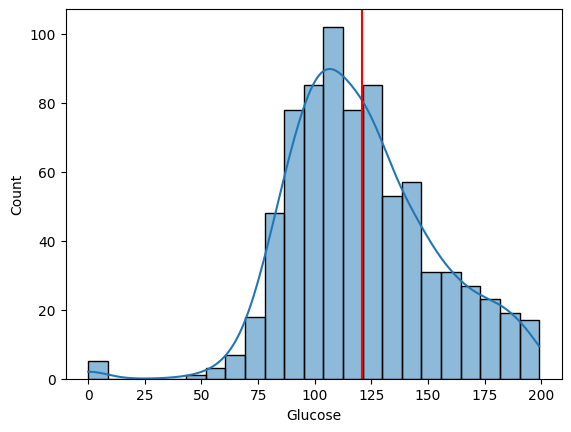

In [89]:
sns.histplot(df['Glucose'],kde = True)
plt.axvline(df['Glucose'].mean(), color='red')
plt.show()

In [90]:
inv_glo = (df['Glucose'] == 0)

median_glucose = df[df['Glucose'] != 0]['Glucose'].median()
df.loc[inv_glo, 'Glucose'] = median_glucose

In [91]:
inv_glo.value_counts()

,count
Glucose,
False,763
True,5


In [92]:
df['BloodPressure'].unique().min()

np.int64(0)

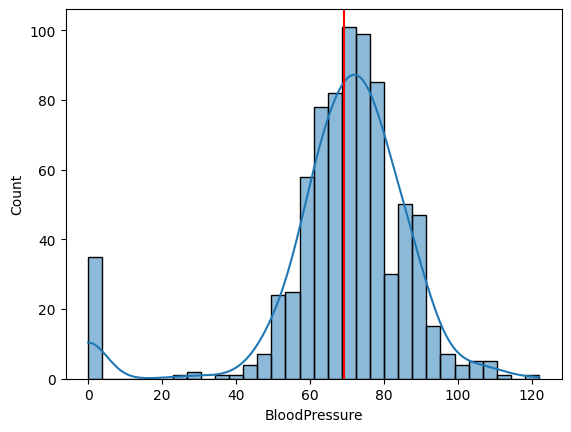

In [93]:
sns.histplot(df['BloodPressure'],kde = True)
plt.axvline(df['BloodPressure'].mean(), color='red')
plt.show()

In [94]:
inv_blood = (df['BloodPressure'] == 0)

median_bloodpressure = df[df['BloodPressure'] != 0]['BloodPressure'].median()
df.loc[inv_blood, 'BloodPressure'] = median_bloodpressure

In [95]:
df['BloodPressure'].skew()

np.float64(0.1418850201030565)

In [96]:
df['BloodPressure'].isin([0]).sum()

np.int64(0)

In [97]:
df['BMI'].value_counts()

,count
BMI,
32.0,13
31.6,12
31.2,12
0.0,11
32.4,10
...,...
49.6,1
24.1,1
41.2,1


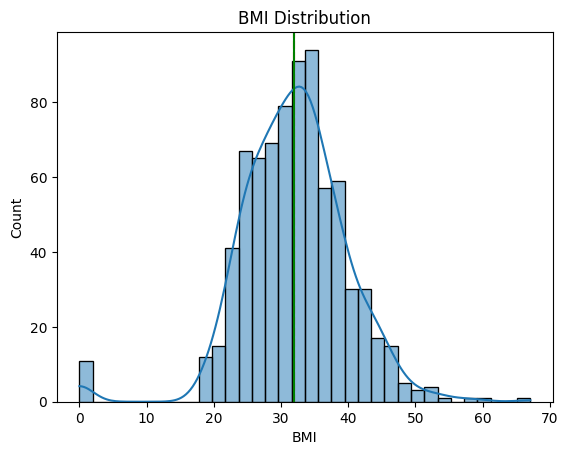

In [98]:
sns.histplot(df['BMI'], kde=True)
plt.axvline(df['BMI'].mean(), color='red', linestyle='--')
plt.axvline(df['BMI'].median(), color='green', linestyle='-')
plt.title('BMI Distribution')
plt.show()

In [99]:
# Identify 0 values in BMI
inv_bmi = (df['BMI'] == 0)

# Calculate median of non-zero values
median_bmi = df[df['BMI'] != 0]['BMI'].median()

# Impute
df.loc[inv_bmi, 'BMI'] = median_bmi

print(f"Imputed {inv_bmi.sum()} values with median: {median_bmi}")
print(f"Remaining zeros in BMI: {(df['BMI'] == 0).sum()}")

Imputed 11 values with median: 32.3
Remaining zeros in BMI: 0


In [100]:
bins = [0, 29, 50, df['Age'].max()]
labels = ['Young', 'Adult', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

Age_Group
Young     396
Adult     291
Senior     81
Name: count, dtype: int64


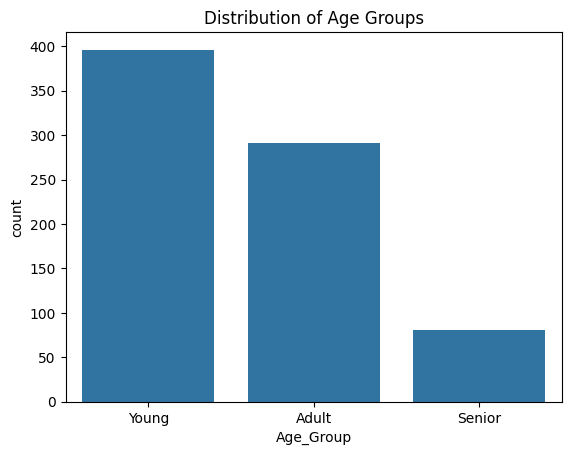

In [101]:
print(df['Age_Group'].value_counts())
sns.countplot(data=df, x='Age_Group')
plt.title('Distribution of Age Groups')
plt.show()

In [102]:
from sklearn.preprocessing import OrdinalEncoder

# Define the order for categories
encoder = OrdinalEncoder(categories=[['Young', 'Adult', 'Senior']])

# Reshape and transform
df['Age_Group_Encoded'] = encoder.fit_transform(df[['Age_Group']])

print("Encoded unique values:", df['Age_Group_Encoded'].unique())

df[['Age_Group', 'Age_Group_Encoded']].head()
"""
# ordinal encoding in Age_Group
# Mapping: Young -> 0, Adult -> 1, Senior -> 2
age_mapping = {'Young': 0, 'Adult': 1, 'Senior': 2}
df['Age_Group_Encoded'] = df['Age_Group'].map(age_mapping)

print("Encoded unique values:", df['Age_Group_Encoded'].unique())
df[['Age_Group', 'Age_Group_Encoded']].head()
"""

Encoded unique values: [1. 0. 2.]


'\n# ordinal encoding in Age_Group\n# Mapping: Young -> 0, Adult -> 1, Senior -> 2\nage_mapping = {\'Young\': 0, \'Adult\': 1, \'Senior\': 2}\ndf[\'Age_Group_Encoded\'] = df[\'Age_Group\'].map(age_mapping)\n\nprint("Encoded unique values:", df[\'Age_Group_Encoded\'].unique())\ndf[[\'Age_Group\', \'Age_Group_Encoded\']].head()\n'

In [103]:
# Summary check for zero values in all features
zero_counts = (df == 0).sum()
print("Zero values per column:")
print(zero_counts)

Zero values per column:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness               227
Insulin                     374
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
Age_Group                     0
Age_Group_Encoded           396
dtype: int64


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   768 non-null    int64   
 2   BloodPressure             768 non-null    int64   
 3   SkinThickness             768 non-null    int64   
 4   Insulin                   768 non-null    int64   
 5   BMI                       768 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   Outcome                   768 non-null    int64   
 9   Age_Group                 768 non-null    category
 10  Age_Group_Encoded         768 non-null    float64 
dtypes: category(1), float64(3), int64(7)
memory usage: 61.0 KB


In [105]:
df = pd.read_csv('https://raw.githubusercontent.com/Wahid-vinchenzo/phitron-Machine-Learning/refs/heads/main/dataset/heart.csv')
df.sample()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
542,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [107]:
# Checking categorical values to see if they need encoding
print("Unique values in 'cp' (Chest Pain):", df['cp'].unique())
print("Unique values in 'thal':", df['thal'].unique())
print("Unique values in 'slope':", df['slope'].unique())

# Although they are integers, these are nominal categories.
# One-Hot Encoding is recommended for 'cp', 'thal', and 'slope'
# to prevent the model from assuming an ordinal relationship.

# Example of how you would encode them:
# df = pd.get_dummies(df, columns=['cp', 'thal', 'slope'], drop_first=True)
# df.head()

Unique values in 'cp' (Chest Pain): [0 1 2 3]
Unique values in 'thal': [3 2 1 0]
Unique values in 'slope': [2 0 1]


In [108]:
# one hot encoding in cp
from sklearn.preprocessing import OneHotEncoder
cp_encoder = OneHotEncoder(sparse_output=False, drop='first')
cp_encoded = cp_encoder.fit_transform(df[['cp']])

cp_df = pd.DataFrame(cp_encoded, columns=cp_encoder.get_feature_names_out(['cp']))
df = pd.concat([df, cp_df], axis=1)
df.drop('cp', axis=1, inplace=True)
df.head()



,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_1,cp_2,cp_3
0,52,1,125,212,0,1,168,0,1.0,2,2,3,0,0.0,0.0,0.0
1,53,1,140,203,1,0,155,1,3.1,0,0,3,0,0.0,0.0,0.0
2,70,1,145,174,0,1,125,1,2.6,0,0,3,0,0.0,0.0,0.0
3,61,1,148,203,0,1,161,0,0.0,2,1,3,0,0.0,0.0,0.0
4,62,0,138,294,1,1,106,0,1.9,1,3,2,0,0.0,0.0,0.0


In [109]:
# onehot encoding in thal
# sparse_output=False is used to return a dense array instead of a sparse matrix.
# This makes it easier to convert the output into a pandas DataFrame.
thai_encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the 'thal' column
thal_encoded = thai_encoder.fit_transform(df[['thal']])

# Create a DataFrame from the encoded values
thal_df = pd.DataFrame(thal_encoded, columns=thai_encoder.get_feature_names_out(['thal']))

# Combine with the main DataFrame and drop the original column
df = pd.concat([df, thal_df], axis=1)
df.drop('thal', axis=1, inplace=True)

display(df.head())

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,thal_1,thal_2,thal_3
0,52,1,125,212,0,1,168,0,1.0,2,2,0,0.0,0.0,0.0,0.0,0.0,1.0
1,53,1,140,203,1,0,155,1,3.1,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,1,125,1,2.6,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,1,161,0,0.0,2,1,0,0.0,0.0,0.0,0.0,0.0,1.0
4,62,0,138,294,1,1,106,0,1.9,1,3,0,0.0,0.0,0.0,0.0,1.0,0.0


In [110]:
#onehot encoding encoding in slope
slope_encoder = OneHotEncoder(sparse_output=False, drop='first')

slope_encoded = slope_encoder.fit_transform(df[['slope']])

slope_df = pd.DataFrame(slope_encoded, columns = slope_encoder.get_feature_names_out(['slope']))
df = pd.concat([df,slope_df], axis = 1)
df.drop('slope', axis = 1, inplace = True)
df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,thal_1,thal_2,thal_3,slope_1,slope_2
0,52,1,125,212,0,1,168,0,1.0,2,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,53,1,140,203,1,0,155,1,3.1,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,70,1,145,174,0,1,125,1,2.6,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,61,1,148,203,0,1,161,0,0.0,1,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,62,0,138,294,1,1,106,0,1.9,3,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [111]:
df.shape

(1025, 19)

In [112]:
df = pd.read_csv("https://raw.githubusercontent.com/Wahid-vinchenzo/phitron-Machine-Learning/refs/heads/main/dataset/tips.csv")

In [113]:
df.shape

(244, 7)

In [114]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [115]:

df.dtypes

,0
total_bill,float64
tip,float64
sex,object
smoker,object
day,object
time,object
size,int64


In [116]:
# Checking unique values for categorical columns in the tips dataset
for col in ['sex', 'smoker', 'day', 'time']:
    print(f"{col}: {df[col].unique()}")

sex: ['Female' 'Male']
smoker: ['No' 'Yes']
day: ['Sun' 'Sat' 'Thur' 'Fri']
time: ['Dinner' 'Lunch']


In [117]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [118]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding is best for binary features in this dataset:
# 'sex', 'smoker', and 'time'

le = LabelEncoder()

# Creating a copy to demonstrate
df_encoded = df.copy()

for col in ['sex', 'smoker', 'time']:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

display(df_encoded.head())

Encoded sex: {'Female': np.int64(0), 'Male': np.int64(1)}
Encoded smoker: {'No': np.int64(0), 'Yes': np.int64(1)}
Encoded time: {'Dinner': np.int64(0), 'Lunch': np.int64(1)}


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,Sun,0,2
1,10.34,1.66,1,0,Sun,0,3
2,21.01,3.50,1,0,Sun,0,3
3,23.68,3.31,1,0,Sun,0,2
4,24.59,3.61,0,0,Sun,0,4


tip_category
Low       146
Medium     91
High        7
Name: count, dtype: int64


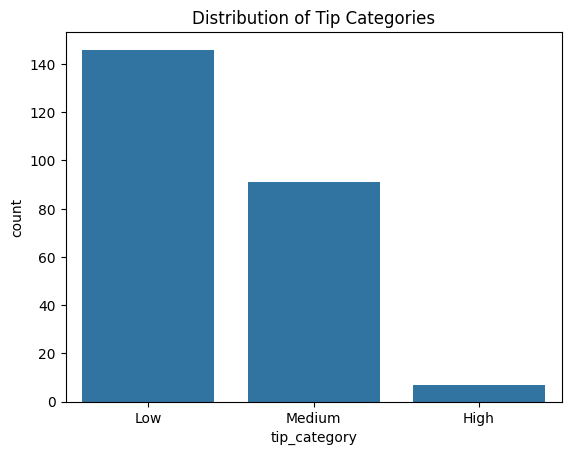

Encoded unique values: [0. 1. 2.]


In [119]:
bins = [0, 3, 6, df['tip'].max()]
labels = ['Low', 'Medium', 'High']
df['tip_category'] = pd.cut(df['tip'], bins=bins, labels=labels, include_lowest=True)

df.drop('tip', axis=1, inplace=True)

print(df['tip_category'].value_counts())
sns.countplot(data=df, x='tip_category')
plt.title('Distribution of Tip Categories')
plt.show()
#ordinal encoding in tip category

od = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
df['tip_category_encoded'] = od.fit_transform(df[['tip_category']])

print("Encoded unique values:", df['tip_category_encoded'].unique())


In [120]:
df

,total_bill,sex,smoker,day,time,size,tip_category,tip_category_encoded
0,16.99,Female,No,Sun,Dinner,2,Low,0.0
1,10.34,Male,No,Sun,Dinner,3,Low,0.0
2,21.01,Male,No,Sun,Dinner,3,Medium,1.0
3,23.68,Male,No,Sun,Dinner,2,Medium,1.0
4,24.59,Female,No,Sun,Dinner,4,Medium,1.0
...,...,...,...,...,...,...,...,...
239,29.03,Male,No,Sat,Dinner,3,Medium,1.0
240,27.18,Female,Yes,Sat,Dinner,2,Low,0.0
241,22.67,Male,Yes,Sat,Dinner,2,Low,0.0
242,17.82,Male,No,Sat,Dinner,2,Low,0.0


In [121]:
df = pd.read_csv('https://raw.githubusercontent.com/Wahid-vinchenzo/phitron-Machine-Learning/refs/heads/main/dataset/CarPrice_Assignment.csv')

In [122]:
df.shape

(205, 26)

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
df.isnull().sum()

In [126]:
X = df.drop('price', axis=1)
y = df['price']

In [127]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,

)

In [128]:
X_train.shape

(164, 25)

In [131]:
X_train.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg'],
      dtype='object')

In [133]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [132]:
print(X_train['fueltype'].unique())

['diesel' 'gas']


In [135]:
ord_categories = ['diesel', 'gas']
o_en = OrdinalEncoder(categories=[ord_categories])

X_train['fueltype_encoded'] = o_en.fit_transform(X_train[['fueltype']])
X_test['fueltype_encoded'] = o_en.transform(X_test[['fueltype']])

In [137]:
X_test.sample(2)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,fueltype_encoded
82,83,3,mitsubishi outlander,gas,turbo,two,hatchback,fwd,front,95.9,...,156,spdi,3.58,3.86,7.0,145,5000,19,24,1.0
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,1.0


In [140]:
X_train.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'fueltype_encoded'],
      dtype='object')

# **`IBM Employee`**

In [142]:
df = pd.read_csv('https://raw.githubusercontent.com/Wahid-vinchenzo/phitron-Machine-Learning/refs/heads/main/dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [143]:
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [144]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [150]:
col_obj = df.select_dtypes(include=['object']).columns
col_obj

col_num = df.select_dtypes(include = ['int64','float64']).columns
col_num

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [155]:
df[col_obj]

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [154]:
df[col_obj].nunique()

,0
Attrition,2
BusinessTravel,3
Department,3
EducationField,6
Gender,2
JobRole,9
MaritalStatus,3
Over18,1
OverTime,2


### Selection of Encoding Techniques for `col_obj` (IBM HR Dataset):

`col_obj` এ থাকা কলামগুলোর জন্য নিচের এনকোডিংগুলো উপযুক্ত:

1.  **Attrition (Binary - Yes/No):**
    *   **Suitable Encoding:** `Label Encoding` বা `Map (0, 1)`।
    *   **Reason:** এটি আমাদের টার্গেট ভেরিয়েবল এবং এতে মাত্র দুটি ক্যাটাগরি আছে।

2.  **BusinessTravel (Ordinal):**
    *   **Suitable Encoding:** `Ordinal Encoding`।
    *   **Reason:** এখানে একটি নির্দিষ্ট ক্রম আছে (Non-Travel < Travel_Rarely < Travel_Frequently)।

3.  **Department & EducationField (Nominal):**
    *   **Suitable Encoding:** `One-Hot Encoding` (pd.get_dummies)।
    *   **Reason:** এগুলোর মধ্যে কোনো গাণিতিক ক্রম নেই এবং ক্যাটাগরির সংখ্যা কম।

4.  **Gender (Binary - Male/Female):**
    *   **Suitable Encoding:** `Label Encoding` বা `One-Hot Encoding` (Drop first)।
    *   **Reason:** যেহেতু মাত্র দুটি ভ্যালু, তাই ০ বা ১ এ রূপান্তর করা সহজ।

5.  **JobRole (Nominal):**
    *   **Suitable Encoding:** `One-Hot Encoding`।
    *   **Reason:** এখানে ৯টি আলাদা রোল আছে যাদের মধ্যে কোনো র্যাঙ্কিং নেই।

6.  **MaritalStatus (Nominal):**
    *   **Suitable Encoding:** `One-Hot Encoding`।
    *   **Reason:** Single, Married, Divorced - এগুলোর মধ্যে কোনো ক্রম নেই।

7.  **Over18 (Constant):**
    *   **Suitable Encoding:** এনকোডিং করার প্রয়োজন নেই (Drop the column)।
    *   **Reason:** সবার ভ্যালু 'Y', তাই এটি মডেলে কোনো প্রভাব ফেলবে না।

8.  **OverTime (Binary - Yes/No):**
    *   **Suitable Encoding:** `Label Encoding` (0, 1)।
    *   **Reason:** এটি একটি সিম্পল বাইনারি ফিচার।

In [156]:
# Categorizing columns by encoding method
one_hot_enc = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
ordinal_enc = ['BusinessTravel']
label_enc = ['Attrition', 'Gender', 'OverTime']
drop_cols = ['Over18']

print("One-Hot columns:", one_hot_enc)
print("Ordinal columns:", ordinal_enc)
print("Label/Binary columns:", label_enc)
print("Columns to drop:", drop_cols)

One-Hot columns: ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
Ordinal columns: ['BusinessTravel']
Label/Binary columns: ['Attrition', 'Gender', 'OverTime']
Columns to drop: ['Over18']


In [157]:
df.drop(drop_cols, axis=1, inplace=True)

In [158]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [160]:
X_train , X_test , y_train , y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
)

**One hot coding**

In [170]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)

# Fit and transform
X_train_ohe = ohe.fit_transform(X_train[one_hot_enc])
X_test_ohe = ohe.transform(X_test[one_hot_enc])

# Get feature names
feature_names = ohe.get_feature_names_out(one_hot_enc)

# Create DataFrames with column names
X_train_encoded = pd.DataFrame(X_train_ohe, columns=feature_names, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_ohe, columns=feature_names, index=X_test.index)

X_train_encoded.head()

,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
1097,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
727,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
254,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1175,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1341,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [171]:
X_train = pd.concat([X_train.drop(one_hot_enc, axis=1), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(one_hot_enc, axis=1), X_test_encoded], axis=1)

In [172]:
X_train.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Researc

### **Ordinal Encoding**

In [174]:
from sklearn.preprocessing import OrdinalEncoder
ord = OrdinalEncoder()
X_train[ordinal_enc] = ord.fit_transform(X_train[ordinal_enc])
X_test[ordinal_enc] = ord.transform(X_test[ordinal_enc])

In [177]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1176 entries, 1097 to 1126
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1176 non-null   int64  
 1   BusinessTravel                     1176 non-null   float64
 2   DailyRate                          1176 non-null   int64  
 3   DistanceFromHome                   1176 non-null   int64  
 4   Education                          1176 non-null   int64  
 5   EmployeeCount                      1176 non-null   int64  
 6   EmployeeNumber                     1176 non-null   int64  
 7   EnvironmentSatisfaction            1176 non-null   int64  
 8   Gender                             1176 non-null   object 
 9   HourlyRate                         1176 non-null   int64  
 10  JobInvolvement                     1176 non-null   int64  
 11  JobLevel                           1176 non-null   int64  

### **label Encoding**

In [180]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode categorical features in X
features_to_encode = ['Gender', 'OverTime']
for col in features_to_encode:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# Encode target variable y
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Encoded features in X_train:", features_to_encode)
print("Encoded target labels (y).")

Encoded features in X_train: ['Gender', 'OverTime']
Encoded target labels (y).


In [183]:
# Check for remaining object/categorical columns in X_train
remaining_objects = X_train.select_dtypes(include=['object']).columns
print(f"Object columns remaining: {list(remaining_objects)}")

# Verification check
(X_train.dtypes == 'object').any()

Object columns remaining: []


np.False_

In [184]:
(X_test.dtypes == 'object').any()

np.False_

In [187]:
# Check if the encoded target array y_test is still of object type
print(f"y_test dtype: {y_test.dtype}")
y_test.dtype == 'object'

y_test dtype: int64


False

In [189]:
X_train.isnull().sum().any()

np.False_

In [190]:
X_test.isnull().sum().any()

np.False_

In [194]:
# Check for null values in numpy arrays y_train and y_test
print(f"Missing values in y_train: {np.isnan(y_train).sum()}")
print(f"Missing values in y_test: {np.isnan(y_test).sum()}")

Missing values in y_train: 0
Missing values in y_test: 0


In [195]:
# Check for null values in y_test using numpy
print(f"Any nulls in y_test: {np.isnan(y_test).any()}")
print(f"Total nulls in y_test: {np.isnan(y_test).sum()}")

Any nulls in y_test: False
Total nulls in y_test: 0


In [198]:
def encode_datasets(train_df, test_df, ohe_cols=None, ordinal_cols=None, label_cols=None):
    """
    A reusable function to encode training and testing datasets.
    Updated to handle unknown categories in One-Hot encoding.
    """
    from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
    import pandas as pd

    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    encoders = {}

    # 1. One-Hot Encoding
    if ohe_cols:
        # handle_unknown='ignore' prevents errors when test data has new categories
        ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

        # Fit on train, transform both
        train_ohe = ohe.fit_transform(train_encoded[ohe_cols])
        test_ohe = ohe.transform(test_encoded[ohe_cols])

        # Create DataFrames
        ohe_features = ohe.get_feature_names_out(ohe_cols)
        train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_features, index=train_encoded.index)
        test_ohe_df = pd.DataFrame(test_ohe, columns=ohe_features, index=test_encoded.index)

        # Concatenate and drop original columns
        train_encoded = pd.concat([train_encoded.drop(ohe_cols, axis=1), train_ohe_df], axis=1)
        test_encoded = pd.concat([test_encoded.drop(ohe_cols, axis=1), test_ohe_df], axis=1)
        encoders['one_hot'] = ohe

    # 2. Ordinal Encoding
    if ordinal_cols:
        # handle_unknown and unknown_value allow processing of unseen categories in test
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        train_encoded[ordinal_cols] = oe.fit_transform(train_encoded[ordinal_cols])
        test_encoded[ordinal_cols] = oe.transform(test_encoded[ordinal_cols])
        encoders['ordinal'] = oe

    # 3. Label/Binary Encoding for features
    if label_cols:
        for col in label_cols:
            le = LabelEncoder()
            train_encoded[col] = le.fit_transform(train_encoded[col])
            # Note: LabelEncoder does not natively handle unknown values easily
            test_encoded[col] = test_encoded[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
            encoders[f'label_{col}'] = le

    return train_encoded, test_encoded, encoders

In [199]:
# Rerunning the demo with the improved function
import pandas as pd

data = {
    'City': ['New York', 'London', 'Paris', 'Tokyo'],
    'Experience': ['Junior', 'Senior', 'Mid', 'Junior'],
    'Remote': ['Yes', 'No', 'Yes', 'No'],
    'Salary': [50, 90, 70, 45]
}
demo_df = pd.DataFrame(data)

train_demo = demo_df.iloc[:2].copy()
test_demo = demo_df.iloc[2:].copy()

# Define encoding columns
ohe_cols = ['City']
ordinal_cols = ['Experience']
label_cols = ['Remote']

# Use the updated function
train_enc, test_enc, encoders = encode_datasets(
    train_demo,
    test_demo,
    ohe_cols=ohe_cols,
    ordinal_cols=ordinal_cols,
    label_cols=label_cols
)

print("Encoded Train Data (City 'London' is reference):")
display(train_enc)

print("\nEncoded Test Data (Paris/Tokyo result in all zeros for City OHE):")
display(test_enc)

Encoded Train Data (City 'London' is reference):


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Experience,Remote,Salary,City_New York
0,0.0,1,50,1.0
1,1.0,0,90,0.0



Encoded Test Data (Paris/Tokyo result in all zeros for City OHE):


,Experience,Remote,Salary,City_New York
2,-1.0,1,70,0.0
3,0.0,0,45,0.0
